In [15]:
using Pkg
Pkg.activate(".")

  Activating project at `~/Desktop/pkgs/MT.jl/wip`


In [17]:
using JLD2
using Enzyme
using DifferentiationInterface
using ForwardDiff
using FiniteDiff
using LinearAlgebra
using Plots

In [123]:
z_arr = jldopen("../../../kivu/tfs_rotated/unrotated.jld2")["z_arr"]
zerr_arr = jldopen("../../../kivu/tfs_rotated/unrotated.jld2")["zerr_arr"]
f_arr = jldopen("../../../kivu/tfs_rotated/unrotated.jld2")["f_arr"]
st_keys = jldopen("../../../kivu/tfs_rotated/unrotated.jld2")["st_keys"]

┌ Warning: type PyCall.PyObject does not exist in workspace; interpreting Array{PyCall.PyObject} as Array{Any}
└ @ JLD2 /Users/asingh933/.julia/packages/JLD2/KyKLQ/src/datasets.jl:128
┌ Warning: type PyCall.PyObject does not exist in workspace; reconstructing
└ @ JLD2 /Users/asingh933/.julia/packages/JLD2/KyKLQ/src/data/reconstructing_datatypes.jl:459


10-element Vector{Any}:
 Reconstruct@PyObject()
 Reconstruct@PyObject()
 Reconstruct@PyObject()
 Reconstruct@PyObject()
 Reconstruct@PyObject()
 Reconstruct@PyObject()
 Reconstruct@PyObject()
 Reconstruct@PyObject()
 Reconstruct@PyObject()
 Reconstruct@PyObject()

In [49]:
get_β(M) = 0.5 * atan((M[1,2] - M[2,1])/(M[1,1] + M[2,2])) * 180/π
function R(θ_p)
    θ = θ_p *π/180
    reshape([cos(θ), -sin(θ), sin(θ), cos(θ)], 2,2)
end

function get_β_from_pars(x)
    X = reshape(x[1:4], 2,2)
    Y = reshape(x[5:8], 2,2)

    Φ = inv(X) *Y
    get_β(Φ)
end

err_Φ_ij(μx, μy, σx², σy²) = sqrt((μx^2* σy² + μy^2* σx²)/ (μx^4))
err_Φ_ij(μx, μy, σ²)= err_Φ_ij(μx, μy, σ², σ²)


function get_β_err(Φ, ΣΦ)
    k = (Φ[1,2]- Φ[2,1])/(Φ[1,1]+ Φ[2,2])
    σ = 0.5 * 180/π * sqrt(
        1/(1+k^2)^2 * inv(Φ[1,1]+ Φ[2,2])^4 * (
            (Φ[1,1] + Φ[2,2])^2 * (ΣΦ[1,2] + ΣΦ[2,1]) +
            (Φ[1,2] + Φ[2,1])^2 * (ΣΦ[1,1] + ΣΦ[2,2])
        )
    )

    return σ
    
end

# function get_θ_from_pars(x)
#     X = reshape(x[1:4], 2,2)
#     Y = reshape(x[5:8], 2,2)

#     P = inv(X) *Y
#     β = get_β(P)

#     P_sym = R(-β) * P * R(-β)

#     l, q = eigen(P_sym)

#     v1 = q[:, 1]
#     v2 = q[:, 2]
#     θ = atan(v1[2]/v1[1]) * 180/π
#     return θ
# end

function get_θ_from_pars(P_sym_)
    # X = reshape(x[1:4], 2,2)
    # Y = reshape(x[5:8], 2,2)

    # P = inv(X) *Y
    # β = get_β(P)

    # P_sym = R(-β) * P * R(-β)


    P_sym = reshape(P_sym_, 2, 2)
    l, q = eigen(P_sym)

    v1 = q[:, 1]
    # v2 = q[:, 2]
    θ = atan(v1[2]/v1[1]) * 180/π
    return θ
end

get_θ_from_pars (generic function with 1 method)

In [117]:
ρₐ_all= [abs.(z_arr[i]).^2 ./(2* π .* f_arr[i]) for i in 1:length(z_arr)]
ϕ_all= [angle.(z_arr[i]) .*180/π for i in 1:length(z_arr)]

for i in 1:length(ϕ_all)
    ϕ_all[i][ϕ_all[i] .<0.] .= ϕ_all[i][ϕ_all[i] .<0.] .+ 180.
end

ρₐerr= [2 .* zerr_arr[i] .* abs.(z_arr[i])./(2* π .* f_arr[i]) for i in 1:10]
ϕerr= [];
for i in 1:10
    r= zerr_arr[i]./abs2.(z_arr[i]);
    err_r= zero(r);
    err_r[r.>1].= NaN;
    err_r[r.<=1].= 180/π .*asin.(zerr_arr[i][r.<=1]./abs2.(z_arr[i][r.<=1]));
    push!(ϕerr, err_r)
end

In [64]:
x_arr = real.(z_arr)
y_arr = imag.(z_arr)

Φ_arr = [zero(x_arr[i]) for i in eachindex(z_arr)]
β_arr = [zero(x_arr[i][:,1,1]) for i in eachindex(z_arr)]
βerr_arr = [zero(x_arr[i][:,1,1]) for i in eachindex(z_arr)]
Φsym_arr = [zero(x_arr[i]) for i in eachindex(z_arr)]
eig_arr = [zero(x_arr[i]) for i in eachindex(z_arr)]

isym_arr = [zero(x_arr[i][:,1,1]) for i in eachindex(z_arr)]
eig_sym_arr = [zero(x_arr[i][:,1,1]) for i in eachindex(z_arr)]

θ_arr = [zero(x_arr[i][:,1,1]) for i in eachindex(z_arr)]
θerr_arr = [zero(x_arr[i][:,1,1]) for i in eachindex(z_arr)]

new_z_arr = [zero(z_arr[i]) for i in eachindex(z_arr)]


for i in eachindex(z_arr)
    for j in axes(z_arr[i], 1)
        P = inv(x_arr[i][j,:,:]) * y_arr[i][j,:,:]
        Φ_arr[i][j,:,:] .= P
        mean_pars = [x_arr[i][j,:,:][:]..., y_arr[i][j,:,:]...]
        std_pars = [zerr_arr[i][j,:,:]..., zerr_arr[i][j,:,:]...]
        
        P_err = err_Φ_ij.(x_arr[i][j,:,:], y_arr[i][j,:,:], zerr_arr[i][j,:,:].^2)

        β = get_β(P)
        β_arr[i][j] = β
        βerr = get_β_err(P, P_err .^ 2)
        βerr_arr[i][j] = βerr

        P_sym = R(-β) * P * R(-β)

        K = kron(R(β), R(-β))
        ΣP_vec = diagm(P_err[:]).^2
        ΣP_sym_vec = K * ΣP_vec * K'
        
        # Φsym_arr[i][j,:,:] .= P_sym
        l, q = eigen(P_sym)

        # v1 = q[:, 1]
        # v2 = q[:, 2]

        gp = DifferentiationInterface.gradient(get_θ_from_pars, AutoFiniteDiff(), P_sym[:])
        # g_pp = DifferentiationInterface.hessian(get_θ_from_pars, AutoEnzyme(), P_sym[:])

        # θ = atan(v1[2]/v1[1]) * 180/π
        # θ_arr[i][j] = θ

        θ = get_θ_from_pars(P_sym[:]) #+ 0.5 * diag(g_pp)' * std_pars
        θerr =  sqrt(sum(gp.^ 2 .* diag(ΣP_sym_vec)))
        θ_arr[i][j] = θ
        θerr_arr[i][j] = θerr
        
        eig_sym_arr[i][j] = norm(R(θ) * P_sym * R(-θ) .- diagm(l), 1)

    end
end

In [65]:
[norm(eig_sym_arr[i], 1) for i in eachindex(z_arr)] .< 1e-10

10-element BitVector:
 1
 1
 1
 1
 1
 1
 1
 1
 1
 1

In [90]:
first((1:length(f_arr[i]))[(f_arr[i] .< 0.01)])

81

In [111]:
inv.(sum(1 ./θerr_arr[i][81:end])) * sum(θ_arr[i][81:end]./(θerr_arr[i][81:end])) ./ length(θ_arr[i][81:end])

0.20928903432920343

In [112]:
sum(θ_arr[i][81:end]) ./ length(θ_arr[i][81:end])

-1.9762322659067986

In [126]:
st_keys[i]

Base.Meta.ParseError: ParseError:
# Error @ /Users/asingh933/Desktop/pkgs/MT.jl/wip/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X23sZmlsZQ==.jl:1:12
st_keys[i].
#          └ ── premature end of input

┌ Warning: Indices Base.OneTo(1) of attribute `linecolor` does not match data indices 2:288.
└ @ Plots /Users/asingh933/.julia/packages/Plots/3u4B6/src/utils.jl:141
┌ Info: Data contains NaNs or missing values, and indices of `linecolor` vector do not match data indices.
│ If you intend elements of `linecolor` to apply to individual NaN-separated segments in the data,
│ pass each segment in a separate vector instead, and use a row vector for `linecolor`. Legend entries
│ may be suppressed by passing an empty label.
│ For example,
│     plot([1:2,1:3], [[4,5],[3,4,5]], label=["y" ""], linecolor=[1 2])
└ @ Plots /Users/asingh933/.julia/packages/Plots/3u4B6/src/utils.jl:143
┌ Warning: Indices Base.OneTo(1) of attribute `markerstrokecolor` does not match data indices 2:288.
└ @ Plots /Users/asingh933/.julia/packages/Plots/3u4B6/src/utils.jl:141
┌ Info: Data contains NaNs or missing values, and indices of `markerstrokecolor` vector do not match data indices.
│ If you intend elements of `mar

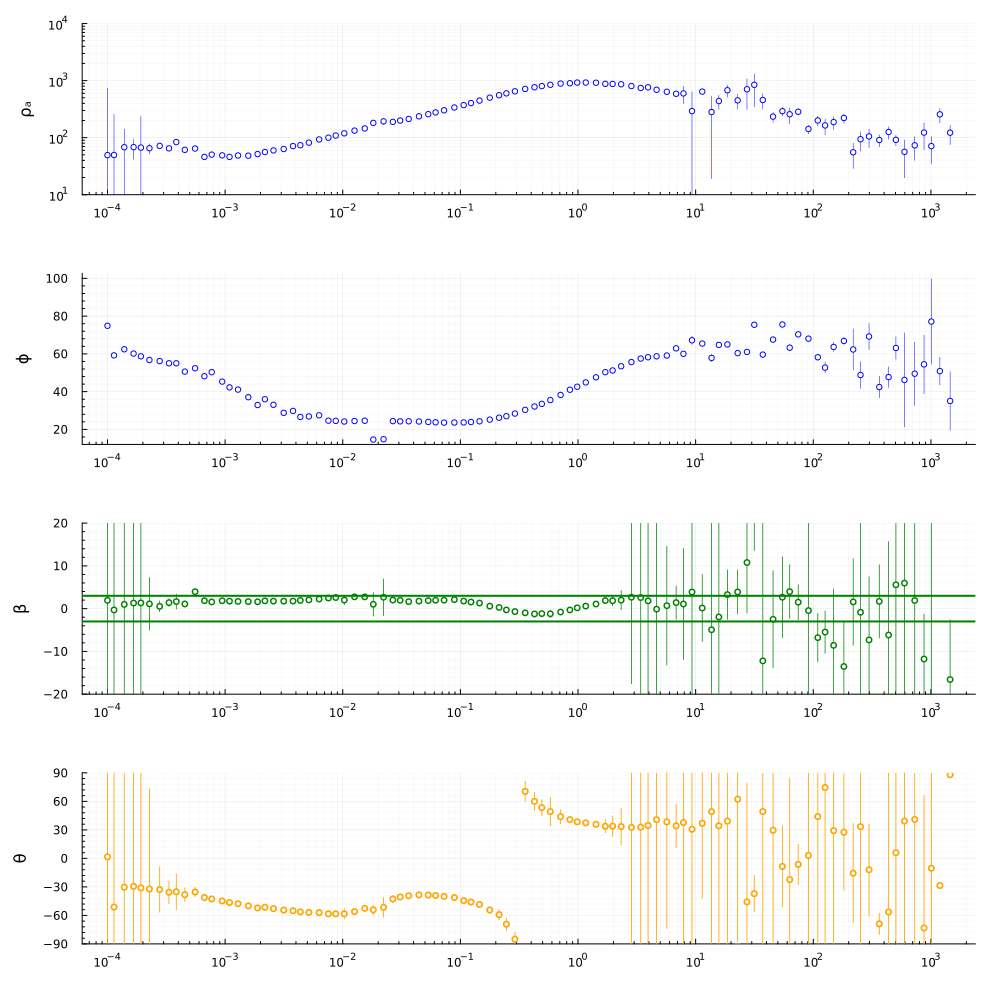

In [133]:
i = 1
colors = [:blue]
p1 = scatter(1 ./f_arr[i], ρₐ_all[i][:,1,2], yerr= (ρₐerr[i][:,1,2]), xscale=:log10, yscale = :log10, ylims = (10, 1e4), markersize= 3, markerstrokecolor= colors, ylabel = "ρₐ", label = false, markercolor = :white, markerstrokewidth = 0.5)
p2 = scatter(1 ./f_arr[i], ϕ_all[i][:,1,2], yerr= (ϕerr[i][:,1,2]), xscale=:log10, markersize= 3, markerstrokecolor= colors, ylabel = "ϕ", label = false, markercolor = :white, markerstrokewidth = 0.5)
p3 = scatter(1 ./f_arr[i], β_arr[i], yerr= (βerr_arr[i]), xscale=:log10, markersize= 3, markerstrokecolor= :green, ylabel = "β", label = false, markercolor = :white, markerstrokewidth = 0.75)
hline!(p3, [-3, 3], label = false, ylims = (-20, 20), color = :green, linewidth = 2)
p4 = scatter(1 ./f_arr[i], θ_arr[i], yerr= (θerr_arr[i]), ylims = (-90, 90), xscale=:log10, markersize= 3, markerstrokecolor= :orange, ylabel = "θ", label = false, markercolor = :white, markerstrokewidth = 0.85)

plot(p1, p2, p3,p4, layout = (4,1), size = (1000, 1000), margin = 4Plots.mm, xticks = 10. .^ (-4:3), minorgrid = true)

In [13]:
i = 2
colors = [:blue]
# p1 = scatter(1 ./f_arr[i], ρₐ_all[i][:,1,2], yerr= (ρₐerr[i][:,1,2]), xscale=:log10, yscale = :log10, ylims = (1, 1e4), markersize= 3, markerstrokecolor= colors, ylabel = "ρₐ", label = false, markercolor = :white, markerstrokewidth = 0.5)
# p2 = scatter(1 ./f_arr[i], ϕ_all[i][:,1,2], yerr= (ϕerr[i][:,1,2]), xscale=:log10, markersize= 3, markerstrokecolor= colors, ylabel = "ϕ", label = false, markercolor = :white, markerstrokewidth = 0.5)
p3 = scatter(1 ./f_arr[i], β_arr[i], yerr= (βerr_arr[i][:,1,2]), xscale=:log10, markersize= 3, markerstrokecolor= :green, ylabel = "β", label = false, markercolor = :white, markerstrokewidth = 0.5)
hline!(p3, [-3, 3], label = false, ylims = (-20, 20), color = :green, linewidth = 3)
p4 = scatter(1 ./f_arr[i], θ_arr[i], yerr= (θerr_arr[i][:,1,2]),  xscale=:log10, markersize= 3, markerstrokecolor= :green, ylabel = "θ", label = false, markercolor = :white, markerstrokewidth = 0.5)
# p5 = scatter(1 ./f_arr[i], θ_arr2[i], xscale=:log10, markersize= 3, markerstrokecolor= :green, ylabel = "θ2", label = false, markercolor = :white, markerstrokewidth = 0.5)

mode_ = :XY
mask_net = filter_station(z_arr[1], zerr_arr[1], f_arr[1], mode_, [1e-2, 10. ^2], [0.5, 0.2]) .&& filter_outlier(ρₐ_all[1], ϕ_all[1], f_arr[1], mode_)

# scatter!(p1, 1 ./f_arr[i][mask_net], ρₐ_all[i][:,1,2][mask_net], xscale=:log10, yscale = :log10, ylims = (1, 1e3), markersize= 3, markerstrokecolor= colors, ylabel = "ρₐ", label = false, markercolor = colors)
# scatter!(p2, 1 ./f_arr[i][mask_net], ϕ_all[i][:,1,2][mask_net], xscale=:log10, markersize= 3, markerstrokecolor= colors, ylabel = "ϕ", label = false, markercolor = colors)
scatter!(p3, 1 ./f_arr[i][mask_net], β_arr[i][mask_net], xscale=:log10, markersize= 2, markerstrokecolor= :green, ylabel = "β", label = false, markercolor = colors)

scatter!(p4, 1 ./f_arr[i][mask_net], θ_arr[i][mask_net], xscale=:log10, markersize= 2, markerstrokecolor= :green, ylabel = "θ", label = false, markercolor = :green)
# scatter!(p5, 1 ./f_arr[i][mask_net], θ_arr2[i][mask_net], xscale=:log10, markersize= 2, markerstrokecolor= :green, ylabel = "θ2", label = false, markercolor = :green)

plot(p3,p4, layout = (5,1), size = (1000, 1000), margin = 3Plots.mm, xticks = 10. .^ (-4:3), minorgrid = true)



UndefVarError: UndefVarError: `ρₐ_all` not defined